# 03 — Logistic Regression: Predicting Entity Default

**Research question:** What structural features of an offshore entity predict whether it will *default* rather than remain *active*?

**Outcome variable:** `is_defaulted` — binary. Active = 0, Defaulted = 1. All other statuses excluded.

**Features:** jurisdiction, leak source, incorporation era (decade bins), primary officer country.


## 0 — Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

BASE_PATH = '/Users/jonasthieme/Documents/GitHub/QSS20-S26/QSS20FinalProject/full-oldb.LATEST/'

relationships = pd.read_csv(BASE_PATH + 'relationships.csv', low_memory=False)
officers      = pd.read_csv(BASE_PATH + 'nodes-officers.csv', low_memory=False)
entities      = pd.read_csv(BASE_PATH + 'nodes-entities.csv', low_memory=False)

print(f"Entities: {entities.shape}")
print(f"Officers: {officers.shape}")
print(f"Relationships: {relationships.shape}")

Entities: (814344, 21)
Officers: (771315, 7)
Relationships: (3339267, 8)


## 1 — Leak Source Filter

In [2]:
LEAK_SOURCES = [
    'Panama Papers',
    'Pandora Papers - Alemán, Cordero, Galindo & Lee (Alcogal)',
    'Pandora Papers - SFM Corporate Services',
    'Pandora Papers - Trident Trust',
    'Pandora Papers - Commence Overseas',
    'Pandora Papers - Alpha Consulting',
    'Pandora Papers - Fidelity Corporate Services',
    'Pandora Papers - CILTrust International',
    'Pandora Papers - Il Shin Corporate Consulting Limited',
    'Pandora Papers - Overseas Management Company (OMC)',
    'Pandora Papers - Asiaciti Trust',
    'Paradise Papers - Appleby',
    'Offshore Leaks',
    'Bahamas Leaks'
]

officers_leaks = officers[officers['sourceID'].isin(LEAK_SOURCES)].copy()
entities_leaks = entities[entities['sourceID'].isin(LEAK_SOURCES)].copy()

print(f"Officers after filter: {len(officers_leaks):,} (was {len(officers):,})")
print(f"Entities after filter: {len(entities_leaks):,} (was {len(entities):,})")

Officers after filter: 498,221 (was 771,315)
Entities after filter: 549,194 (was 814,344)


## 2 — Outcome Variable: Active vs. Defaulted

In [3]:
# Keep only Active and Defaulted rows
model_df = entities_leaks[
    entities_leaks['status'].isin(['Active', 'Defaulted'])
].copy()

model_df['is_defaulted'] = (model_df['status'] == 'Defaulted').astype(int)

print(f"Active:    {(model_df['is_defaulted'] == 0).sum():,}")
print(f"Defaulted: {(model_df['is_defaulted'] == 1).sum():,}")
print(f"Total:     {len(model_df):,}")
print(f"Default rate: {model_df['is_defaulted'].mean():.1%}")

Active:    116,021
Defaulted: 100,090
Total:     216,111
Default rate: 46.3%


## 3 — Feature Engineering

In [4]:
# ── 3a. Incorporation era bins ────────────────────────────────────────────────
model_df['incorporation_date'] = pd.to_datetime(
    model_df['incorporation_date'], format='mixed', errors='coerce'
)
model_df['incorporation_year'] = model_df['incorporation_date'].dt.year

def year_to_era(year):
    if pd.isna(year):  return 'Unknown'
    year = int(year)
    if year < 1990:    return 'Pre-1990'
    elif year < 2000:  return '1990s'
    elif year < 2010:  return '2000s'
    elif year < 2016:  return '2010-2015'
    elif year < 2020:  return '2016-2019'   # post-Panama Papers era
    else:              return '2020+'

model_df['incorporation_era'] = model_df['incorporation_year'].apply(year_to_era)

print("Era distribution within Active/Defaulted set:")
print(model_df.groupby('incorporation_era')['is_defaulted'].agg(['count','mean']).rename(
    columns={'count': 'n', 'mean': 'default_rate'}
).round(3))

Era distribution within Active/Defaulted set:
                        n  default_rate
incorporation_era                      
1990s               45053         0.780
2000s              120332         0.428
2010-2015           41796         0.240
2016-2019            1548         0.000
2020+                   1         0.000
Pre-1990             4466         0.769
Unknown              2915         0.000


In [12]:
# ── 3b. Primary officer country per entity ────────────────────────────────────
# NOTE: officer 'countries' field can contain semicolon-joined multi-values
# e.g. 'Thailand;British Virgin Islands;Indonesia'
# Fix: explode on semicolons BEFORE taking the mode, so each country is
# treated as a separate observation rather than a single compound string.
officer_of_links = relationships[
    relationships['rel_type'] == 'officer_of'
][['node_id_start', 'node_id_end']]

entity_officer = officer_of_links.merge(
    officers_leaks[['node_id', 'countries']].rename(columns={'countries': 'officer_country'}),
    left_on='node_id_start', right_on='node_id'
).drop(columns='node_id')

# Explode semicolons so 'UK;BVI' becomes two rows, then strip whitespace
entity_officer['officer_country'] = entity_officer['officer_country'].str.split(';')
entity_officer = entity_officer.explode('officer_country')
entity_officer['officer_country'] = entity_officer['officer_country'].str.strip()

entity_primary_country = (
    entity_officer[
        entity_officer['officer_country'].notna() &
        ~entity_officer['officer_country'].isin(['Not identified', 'Not Identified', ''])
    ]
    .groupby('node_id_end')['officer_country']
    .agg(lambda x: x.mode()[0])
    .reset_index()
    .rename(columns={'node_id_end': 'node_id', 'officer_country': 'primary_officer_country'})
)

model_df = model_df.merge(entity_primary_country, on='node_id', how='left')
print(f"Officer country coverage: {model_df['primary_officer_country'].notna().mean():.1%}")

# Sanity check — confirm no semicolons remain
has_semi = model_df['primary_officer_country'].dropna().str.contains(';').sum()
print(f"Entries still containing semicolons: {has_semi} (should be 0)")

KeyError: 'primary_officer_country'

In [6]:
# ── 3c. Simplify high-cardinality features ────────────────────────────────────
TOP_N_JURISDICTIONS = 15
TOP_N_COUNTRIES     = 10

# Jurisdiction
top_j = model_df['jurisdiction_description'].value_counts().head(TOP_N_JURISDICTIONS).index
model_df['jurisdiction_simplified'] = model_df['jurisdiction_description'].where(
    model_df['jurisdiction_description'].isin(top_j), other='Other'
)

# Leak source — consolidate Pandora sub-providers
def simplify_source(s):
    if pd.isna(s):          return 'Unknown'
    if 'Pandora' in s:      return 'Pandora Papers'
    return s

model_df['source_simplified'] = model_df['sourceID'].apply(simplify_source)

# Officer country
top_c = model_df['primary_officer_country'].value_counts().head(TOP_N_COUNTRIES).index
model_df['officer_country_simplified'] = model_df['primary_officer_country'].where(
    model_df['primary_officer_country'].isin(top_c), other='Other/Unknown'
).fillna('Other/Unknown')

print("Default rate by jurisdiction (top 10):")
print(
    model_df.groupby('jurisdiction_simplified')['is_defaulted']
    .agg(['count','mean']).rename(columns={'count':'n','mean':'default_rate'})
    .sort_values('default_rate', ascending=False).head(10).round(3)
)

print("\nDefault rate by leak source:")
print(
    model_df.groupby('source_simplified')['is_defaulted']
    .agg(['count','mean']).rename(columns={'count':'n','mean':'default_rate'})
    .sort_values('default_rate', ascending=False).round(3)
)

Default rate by jurisdiction (top 10):
                              n  default_rate
jurisdiction_simplified                      
Niue                       7265         0.998
Bahamas                   12651         0.841
Nevada                      970         0.634
Panama                    28314         0.564
Seychelles                12552         0.500
British Virgin Islands   118288         0.474
British Anguilla           2922         0.361
Samoa                     10150         0.215
United Kingdom              109         0.037
Hong Kong                   566         0.016

Default rate by leak source:
                        n  default_rate
source_simplified                      
Panama Papers      155817         0.642
Offshore Leaks      46003         0.000
Pandora Papers      14291         0.000


## 4 — One-Hot Encoding & Train/Test Split

In [7]:
FEATURE_COLS = [
    'jurisdiction_simplified',
    'source_simplified',
    'incorporation_era',
    'officer_country_simplified'
]
TARGET_COL = 'is_defaulted'

model_clean = model_df[FEATURE_COLS + [TARGET_COL]].dropna(subset=FEATURE_COLS)

print(f"Rows before dropna: {len(model_df):,}")
print(f"Rows after dropna:  {len(model_clean):,}")
print(f"Dropped: {len(model_df) - len(model_clean):,} ({(len(model_df)-len(model_clean))/len(model_df):.1%})")

X = pd.get_dummies(model_clean[FEATURE_COLS], drop_first=True)
y = model_clean[TARGET_COL]

print(f"\nFeature matrix: {X.shape}")
print(f"Default rate in final set: {y.mean():.1%}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Rows before dropna: 216,111
Rows after dropna:  216,111
Dropped: 0 (0.0%)

Feature matrix: (216111, 33)
Default rate in final set: 46.3%
Train: 172,888 | Test: 43,223


## 5 — Logistic Regression

In [8]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        penalty='l2',
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
        solver='lbfgs'
    ))
])

pipe.fit(X_train, y_train)

y_pred  = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]
auc     = roc_auc_score(y_test, y_proba)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Active', 'Defaulted']))
print(f"ROC-AUC: {auc:.3f}")

=== Classification Report ===
              precision    recall  f1-score   support

      Active       0.89      0.77      0.82     23205
   Defaulted       0.77      0.89      0.82     20018

    accuracy                           0.82     43223
   macro avg       0.83      0.83      0.82     43223
weighted avg       0.83      0.82      0.82     43223

ROC-AUC: 0.906


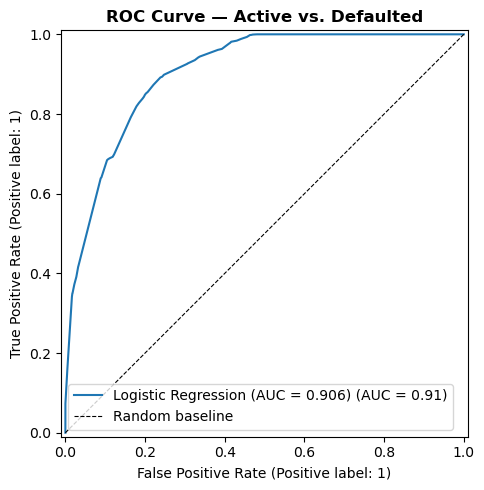

In [9]:
# ── ROC curve ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(
    y_test, y_proba, ax=ax,
    name=f'Logistic Regression (AUC = {auc:.3f})'
)
ax.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_title('ROC Curve — Active vs. Defaulted', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../output/viz5_roc_curve.png', dpi=150)
plt.show()

## 6 — Coefficient Plot

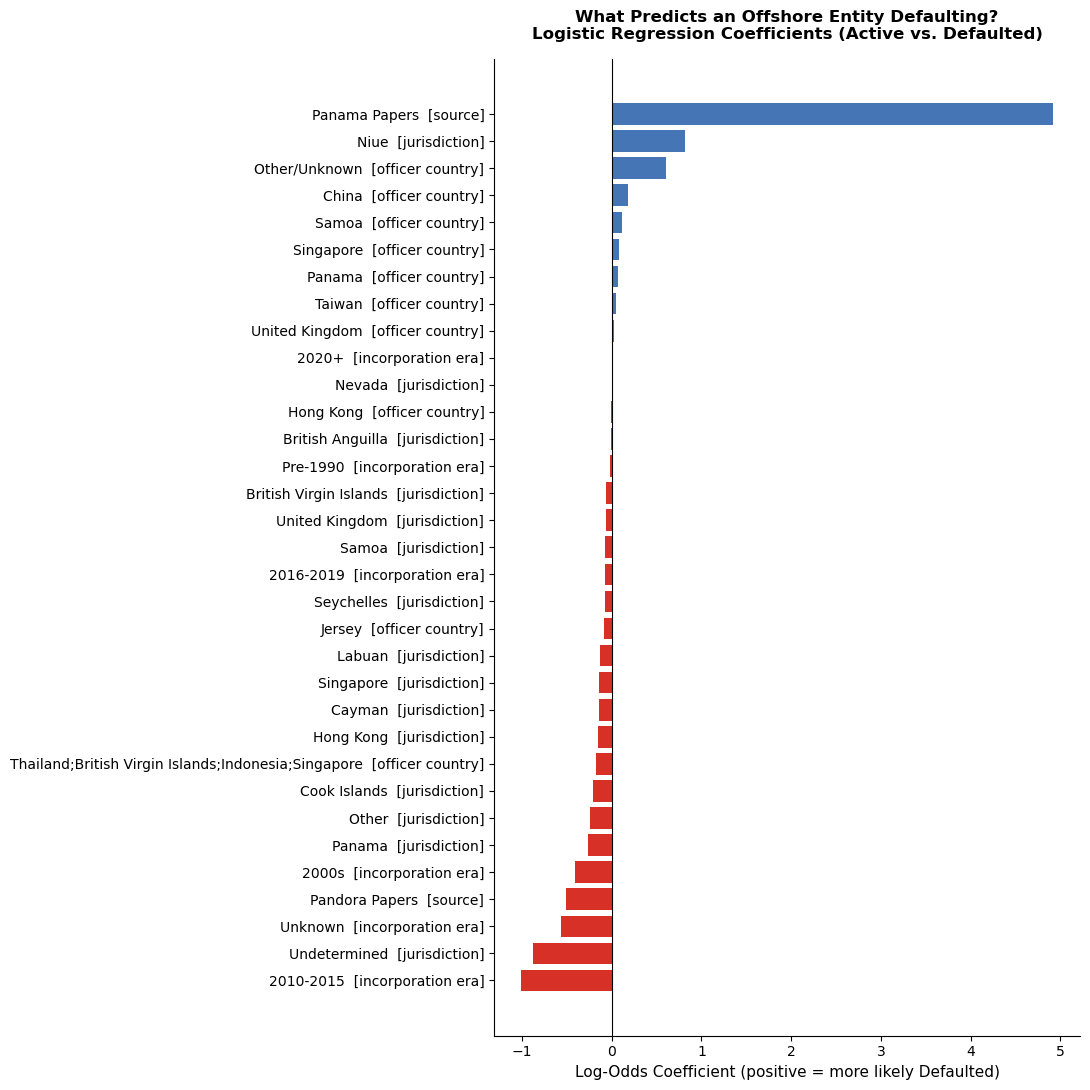


Top 5 features predicting DEFAULT:
                                 feature  coefficient
        officer_country_simplified_Samoa     0.112726
        officer_country_simplified_China     0.176142
officer_country_simplified_Other/Unknown     0.601345
            jurisdiction_simplified_Niue     0.816969
         source_simplified_Panama Papers     4.922252

Top 5 features predicting ACTIVE (negative = less likely defaulted):
                             feature  coefficient
         incorporation_era_2010-2015    -1.014171
jurisdiction_simplified_Undetermined    -0.876243
           incorporation_era_Unknown    -0.566398
    source_simplified_Pandora Papers    -0.508996
             incorporation_era_2000s    -0.414580


In [10]:
coef_df = pd.DataFrame({
    'feature':     X.columns,
    'coefficient': pipe.named_steps['lr'].coef_[0]
}).sort_values('coefficient')

# Top 20 most positive + top 20 most negative
plot_df = pd.concat([
    coef_df.head(20),
    coef_df.tail(20)
]).drop_duplicates().sort_values('coefficient')

# Clean up feature labels for readability
def clean_label(s):
    # Remove prefix like 'jurisdiction_simplified_' etc.
    for prefix in ['jurisdiction_simplified_', 'source_simplified_',
                   'incorporation_era_', 'officer_country_simplified_']:
        if s.startswith(prefix):
            cat = prefix.replace('_simplified_','').replace('_',' ').strip()
            val = s[len(prefix):]
            return f"{val}  [{cat}]"
    return s

plot_df['label'] = plot_df['feature'].apply(clean_label)

colors = ['#4575b4' if c > 0 else '#d73027' for c in plot_df['coefficient']]

fig, ax = plt.subplots(figsize=(11, 11))
ax.barh(plot_df['label'], plot_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Log-Odds Coefficient (positive = more likely Defaulted)', fontsize=11)
ax.set_title(
    'What Predicts an Offshore Entity Defaulting?\n'
    'Logistic Regression Coefficients (Active vs. Defaulted)',
    fontsize=12, fontweight='bold', pad=14
)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../output/viz6_coef_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features predicting DEFAULT:")
print(coef_df.tail(5)[['feature','coefficient']].to_string(index=False))
print("\nTop 5 features predicting ACTIVE (negative = less likely defaulted):")
print(coef_df.head(5)[['feature','coefficient']].to_string(index=False))

## 7 — Summary Table for LaTeX

In [11]:
summary = pd.DataFrame({
    'Metric': [
        'Training observations', 'Test observations',
        'Default rate (full set)', 'Features (one-hot expanded)',
        'Accuracy', 'Precision (Defaulted)', 'Recall (Defaulted)',
        'F1 (Defaulted)', 'ROC-AUC'
    ],
    'Value': [
        f"{len(X_train):,}",
        f"{len(X_test):,}",
        f"{y.mean():.1%}",
        str(X.shape[1]),
        f"{accuracy_score(y_test, y_pred):.3f}",
        f"{precision_score(y_test, y_pred):.3f}",
        f"{recall_score(y_test, y_pred):.3f}",
        f"{f1_score(y_test, y_pred):.3f}",
        f"{auc:.3f}"
    ]
})

print(summary.to_string(index=False))
summary.to_csv('../output/table1_logistic_regression_summary.csv', index=False)
coef_df.to_csv('../output/table2_logistic_regression_coefficients.csv', index=False)
print("\nSaved: output/table1_logistic_regression_summary.csv")
print("Saved: output/table2_logistic_regression_coefficients.csv")

                     Metric   Value
      Training observations 172,888
          Test observations  43,223
    Default rate (full set)   46.3%
Features (one-hot expanded)      33
                   Accuracy   0.822
      Precision (Defaulted)   0.765
         Recall (Defaulted)   0.888
             F1 (Defaulted)   0.822
                    ROC-AUC   0.906

Saved: output/table1_logistic_regression_summary.csv
Saved: output/table2_logistic_regression_coefficients.csv


## Notes for Paper (Methods section)

- **Outcome:** `is_defaulted` — binary indicator. Active = 0, Defaulted = 1. Entities with any other status (Dissolved, Dead, NaN, etc.) excluded to preserve a clean economic contrast: entities still operating vs. those that fell into default.
- **Features:** (1) Jurisdiction — top 15 by frequency, remainder collapsed to 'Other'. (2) Leak source — Pandora Papers sub-providers consolidated into one category, yielding 5 source groups. (3) Incorporation era — decade bins split at 2016 to capture post-Panama Papers behavioral change. (4) Primary officer country — modal officer country linked via `officer_of` relationships; top 10 + 'Other/Unknown'.
- **Encoding:** All categorical features one-hot encoded (`pd.get_dummies`, `drop_first=True`).
- **Split:** 80/20 stratified train/test, random seed 42.
- **Model:** L2-regularized logistic regression (`sklearn` `lbfgs` solver, `class_weight='balanced'`, `max_iter=1000`). Features standardized via `StandardScaler` prior to fitting.
- **Evaluation:** Accuracy, precision, recall, F1 (Defaulted class), ROC-AUC.
- **Interpretation:** Positive coefficients indicate features associated with higher probability of default; negative with remaining active. Coefficients are log-odds.